In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# 04h — Union-style episode re-entry

A 2021–2024 development reconstruction tests one extra same-side entry per signal episode, using LSTM DZ55 and SVM DZ75 with 64 causal price, channel and positioning features.
Five blocked 80/20 folds use an eight-bar embargo; both arms retain TP200/SL100, a one-M15 hold, M1 stop-first execution and 10 bps round-trip costs.
Trades rise from 948 to 1,231, but the extra trades lose 20.58% net; the candidate fails development and the original frozen Union is unchanged.

In [2]:
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

CACHE = CODE_ROOT / "experiments" / "cache" / "union_v1_episode_reentry"
UNION = CODE_ROOT / "experiments" / "cache" / "qualified_union_v1"

def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

summary = json.loads((CACHE / "summary.json").read_text(encoding="utf-8"))
manifest = json.loads((CACHE / "manifest.json").read_text(encoding="utf-8"))
stage_manifest = json.loads((CACHE / "development_artifacts.json").read_text(encoding="utf-8"))
protocol = json.loads((CACHE / "frozen_protocol.json").read_text(encoding="utf-8"))

for filename, expected in manifest["artifact_hashes"].items():
    assert sha256(CACHE / filename) == expected, filename
for filename, expected in stage_manifest["artifact_hashes"].items():
    assert sha256(CACHE / filename) == expected, filename
for filename, expected in manifest["union_dependency_hashes"].items():
    assert sha256(UNION / filename) == expected, filename
assert manifest["protocol_sha256"] == protocol["protocol_sha256"]
assert protocol["policy_grid"] == []
assert protocol["models"] == ["lstm_dz55", "svm_linear_dz75"]
assert len(protocol["features"]) == 64
assert {"funding_rate", "funding_z", "oi_chg_15m", "oi_chg_1h", "oi_chg_4h", "oi_z"}.issubset(protocol["features"])
assert manifest["lockbox_2026_q2_used"] is False

## 1. Fixed development protocol

The experiment asks one narrow question: can a second entry inside a signal
episode increase frequency by at least 15% without reducing net return overall,
for LONG, or for SHORT?

- Development is `[2021-01-01, 2025-01-01)` with five disjoint blocked
  80/20 folds and an eight-M15-bar embargo.
- LSTM predicts the next-M15 DZ55 class with sequence 32, hidden size 64, ten
  epochs, seed 42 and directional confidence ≥0.75.
- Linear SVM predicts DZ75 with `C=0.1`; its frozen threshold is zero, so the
  predicted class controls abstention.
- Active members must agree; an opposite pair is vetoed to WAIT.
- Both arms use TP 200 bps, SL 100 bps, one-M15-bar hold and 5 bps per side.
- There is one candidate, no threshold search and no policy grid.

In [3]:
from IPython.display import Markdown
fold_manifest = pd.read_parquet(CACHE / "development_fold_manifest.parquet")
training = pd.read_csv(CACHE / "development_training_audit.csv")
fold_rows = []
for fold_id, fold in fold_manifest.groupby("fold_id", sort=True):
    fit = fold.loc[fold["role"].eq("fit")]
    test = fold.loc[fold["role"].eq("test")]
    assert fit["position"].max() + 8 < test["position"].min()
    assert fit["union_target_time"].max() < test["decision_time"].min()
    fold_rows.append({
        "fold": int(fold_id), "fit_rows": len(fit), "test_rows": len(test),
        "fit_end": fit["decision_time"].max(), "test_start": test["decision_time"].min(),
    })
assert fold_manifest["fold_id"].nunique() == 5
assert fold_manifest.loc[fold_manifest["role"].eq("test"), "row_key"].is_unique
assert training["preprocessing_fit_only"].astype(bool).all()
assert training["lstm_probabilities_finite"].astype(bool).all()

feature_groups = pd.DataFrame([
    {"group": "Market / order flow", "examples": "returns, ranges, volume, OFI, taker imbalance"},
    {"group": "Funding / open interest", "examples": "funding_rate/z, OI changes/acceleration/z, price×OI, missing/staleness"},
    {"group": "Risk / transferred channels", "examples": "realised volatility, semivariance, drawdown, channel position/slope, wicks"},
])
display(Markdown('Method: Five development blocks retain their causal train/test boundaries and eight-bar embargo.'))
display(pd.DataFrame(fold_rows))
display(Markdown('No later evaluation period contributes to training.'))
display(Markdown('Method: Feature groups count the exact shared 64-column inputs to both models.'))
display(feature_groups)
display(Markdown('Funding and open interest are included alongside price and channel features.'))

Method: Five development blocks retain their causal train/test boundaries and eight-bar embargo.

,fold,fit_rows,test_rows,fit_end,test_start
0,0,22424,5598,2021-08-23 05:30:00+00:00,2021-08-23 07:45:00+00:00
1,1,22429,5599,2022-06-11 08:45:00+00:00,2022-06-11 11:00:00+00:00
2,2,22428,5599,2023-03-30 11:15:00+00:00,2023-03-30 13:30:00+00:00
3,3,22429,5599,2024-01-16 12:30:00+00:00,2024-01-16 14:45:00+00:00
4,4,22429,5599,2024-11-03 13:45:00+00:00,2024-11-03 16:00:00+00:00


No later evaluation period contributes to training.

Method: Feature groups count the exact shared 64-column inputs to both models.

,group,examples
0,Market / order flow,"returns, ranges, volume, OFI, taker imbalance"
1,Funding / open interest,"funding_rate/z, OI changes/acceleration/z, pri..."
2,Risk / transferred channels,"realised volatility, semivariance, drawdown, c..."


Funding and open interest are included alongside price and channel features.

## 2. Paired scheduling and trade funnel

An episode is a maximal consecutive run of one non-zero Union side. The control
ledger is frozen first. The candidate may then accept the earliest qualified
signal bar skipped by control, at most once per episode, provided the next-bar
entry does not overlap any control or prior extra. Selection uses timestamps,
side and occupancy only—never realised PnL or a future confidence value.

The control ledger remains an exact subset of the candidate ledger. Every entry
is replayed on its native one-minute path; a same-minute TP/SL ambiguity is
stop-first, otherwise first touch wins.

In [4]:
from IPython.display import Markdown
predictions = pd.read_parquet(CACHE / "development_oof_predictions.parquet")
signals = pd.read_parquet(CACHE / "development_signals.parquet")
episodes = pd.read_parquet(CACHE / "development_episode_table.parquet")
selected = pd.read_parquet(CACHE / "development_selected_reentries.parquet")
control_ledger = pd.read_parquet(CACHE / "development_control_ledger.parquet")
reentry_ledger = pd.read_parquet(CACHE / "development_reentry_ledger.parquet")
candidate_ledger = pd.read_parquet(CACHE / "development_candidate_ledger.parquet")
development = summary["development"]

probability = predictions[["p_short_lstm", "p_flat_lstm", "p_long_lstm"]].to_numpy(float)
assert predictions["row_key"].is_unique and np.isfinite(probability).all()
assert np.allclose(probability.sum(axis=1), 1.0)
assert selected.groupby("episode_id").size().max() <= 1
assert candidate_ledger["entry_time"].is_unique
assert candidate_ledger["trade_key"].is_unique
assert set(control_ledger["trade_key"]).issubset(set(candidate_ledger["trade_key"]))
assert set(reentry_ledger["signal_time"]) == set(selected["signal_time"])

funnel = pd.DataFrame([
    {"arm": "union_v1_style_control", "trades": len(control_ledger), "trades_per_day": development["control_trades_per_day"]},
    {"arm": "episode_reentry_candidate", "trades": len(candidate_ledger), "trades_per_day": development["candidate_trades_per_day"]},
])
display(Markdown('Method: The candidate adds at most the earliest non-overlapping entry in each same-side episode.'))
display(funnel.round(3))
display(Markdown('Trades increase by 283, from 948 to 1,231.'))

Method: The candidate adds at most the earliest non-overlapping entry in each same-side episode.

,arm,trades,trades_per_day
0,union_v1_style_control,948,3.251
1,episode_reentry_candidate,1231,4.221


Trades increase by 283, from 948 to 1,231.

## 3. Economics: frequency passed, quality failed

The candidate easily passes the count requirement (1,231 versus required
1,091), and both directions have ample trades. That is only the frequency gate.
The reconstructed control has no gross edge before costs, while the extra route
has a small positive gross return that is far below its 10-bps round-trip cost.
Consequently, total, LONG, SHORT and fold-stability gates all fail.

Method: Both ledgers use identical M1 execution and 10 bps round-trip costs.

,route,trades,LONG,SHORT,gross_pct,cost_pct,net_pct
0,control,948,488,460,-2.89,94.8,-97.69
1,extra only,283,141,142,7.72,28.3,-20.58
2,candidate,1231,629,602,4.83,123.1,-118.27


The incremental route loses 20.58% Net.

Method: Total, LONG and SHORT results are checked within the same development folds.

,fold_id,control_trades,reentry_trades,control_net_pct,incremental_net_pct,candidate_net_pct
0,0,27,9,-9.20,-1.78,-10.98
1,1,337,94,-26.47,-1.08,-27.55
2,2,65,18,-8.38,1.89,-6.49
3,3,290,99,-32.61,-9.23,-41.84
4,4,229,63,-21.03,-10.38,-31.41


Higher frequency does not meet the two-sided quality requirement.

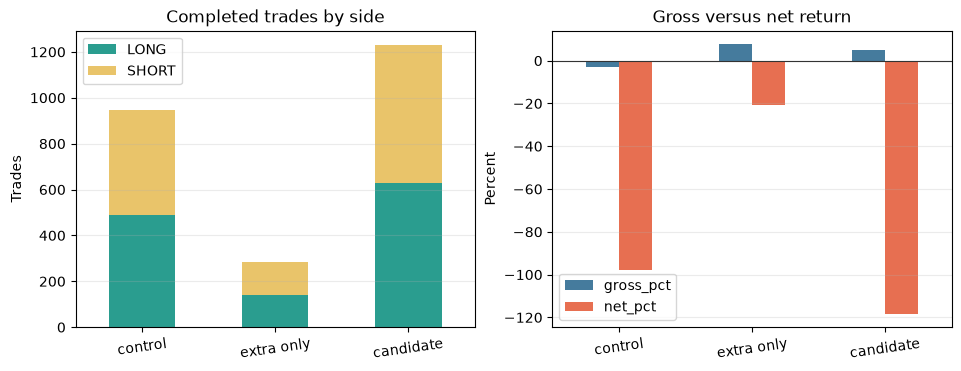

In [5]:
from IPython.display import Markdown
control = development["control"]
candidate = development["candidate"]
incremental = development["incremental"]
fold_metrics = pd.read_csv(CACHE / "development_fold_metrics.csv")

economics = pd.DataFrame([
    {"route": "control", "trades": control["trades"], "LONG": control["long_trades"], "SHORT": control["short_trades"], "gross_pct": 100*control["gross_return"], "cost_pct": 100*control["cost_return"], "net_pct": 100*control["net_return"]},
    {"route": "extra only", "trades": incremental["trades"], "LONG": incremental["long_trades"], "SHORT": incremental["short_trades"], "gross_pct": 100*incremental["gross_return"], "cost_pct": 100*incremental["cost_return"], "net_pct": 100*incremental["net_return"]},
    {"route": "candidate", "trades": candidate["trades"], "LONG": candidate["long_trades"], "SHORT": candidate["short_trades"], "gross_pct": 100*candidate["gross_return"], "cost_pct": 100*candidate["cost_return"], "net_pct": 100*candidate["net_return"]},
])
display(Markdown('Method: Both ledgers use identical M1 execution and 10 bps round-trip costs.'))
display(economics.round(2))
display(Markdown('The incremental route loses 20.58% Net.'))
display(Markdown('Method: Total, LONG and SHORT results are checked within the same development folds.'))
display(fold_metrics.assign(
    control_net_pct=100*fold_metrics["control_net_return"],
    incremental_net_pct=100*fold_metrics["incremental_net_return"],
    candidate_net_pct=100*fold_metrics["candidate_net_return"],
)[["fold_id", "control_trades", "reentry_trades", "control_net_pct", "incremental_net_pct", "candidate_net_pct"]].round(2))
display(Markdown('Higher frequency does not meet the two-sided quality requirement.'))


fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), layout="constrained")
economics.plot.bar(x="route", y=["LONG", "SHORT"], stacked=True, ax=axes[0], color=["#2a9d8f", "#e9c46a"])
economics.plot.bar(x="route", y=["gross_pct", "net_pct"], ax=axes[1], color=["#457b9d", "#e76f51"])
axes[0].set(title="Completed trades by side", xlabel="", ylabel="Trades")
axes[1].axhline(0, color="#333333", linewidth=.8)
axes[1].set(title="Gross versus net return", xlabel="", ylabel="Percent")
for axis in axes:
    axis.grid(axis="y", alpha=.25)
    axis.tick_params(axis="x", rotation=8)
plt.show()

## 4. Decision

More entries do not improve net performance; the registered candidate is rejected and is not evaluated on H1, forward or Q2.

In [6]:
from IPython.display import Markdown
gates = development["gates"]
gate_table = pd.DataFrame(
    [(name, value) for name, value in gates.items() if isinstance(value, bool)],
    columns=["gate", "passed"],
)
display(Markdown('Method: Frequency and economic non-inferiority are assessed under the single registered candidate.'))
display(gate_table)
display(Markdown('The candidate fails development and the original Union is retained.'))

assert gates["frequency_gain"] is True
assert gates["control_total_positive"] is False
assert gates["candidate_total_noninferior"] is False
assert gates["candidate_long_noninferior"] is False
assert gates["candidate_short_noninferior"] is False
assert gates["incremental_total_nonnegative"] is False
assert gates["development_pass"] is False
assert summary["decision"] == "development_fail_keep_union_v1"
assert summary["h1_loaded"] is False
assert summary["forward_loaded"] is False
assert summary["lockbox_2026_q2_used"] is False
assert not any(path.name.startswith(("h1_", "forward_")) for path in CACHE.iterdir())


Method: Frequency and economic non-inferiority are assessed under the single registered candidate.

,gate,passed
0,audit_clean,True
1,candidate_long_noninferior,False
2,candidate_minimum_long_trades,True
3,candidate_minimum_short_trades,True
4,candidate_short_noninferior,False
5,candidate_total_noninferior,False
6,control_long_positive,False
7,control_short_positive,False
8,control_three_positive_folds,False
9,control_total_positive,False


The candidate fails development and the original Union is retained.